# CRNsemble Demo: Expansion of the Applications of the Biocrnpyler for Ensemble Generation

This jupyter notebook serves as a demo on how to use the CRNsemble package for generating ensemble of kinetic parameters for a metabolic reaction network. The CRNsemble is heavily in compliance with the Biocrnpyler package, however, massive adjustments were on this package to ensure the conservation of mass balance, flux setting of intermediate reactions, and setting the model parameters. 

<b>Note</b>: This demo tests the applicability of the CRNsemble on a toy model. While the current version merely generates the ensemble, the ultimate goal is to select the optimal solution through optimization methods.

## Notebook Roadmap

This demo follows a simple pipeline:

1. Configure the runtime and install dependencies.
2. Import CRNsemble modules and helper libraries.
3. Build an ensemble of CRN models from reaction-network inputs.
4. Simulate each ensemble member over time using bioscrape via SBML.
5. Visualize concentration trajectories across the ensemble.

The code cells below are preserved as-is, and these notes are added to make each stage easier to follow.

In [9]:
%%capture
# Install the dependencies

# !pip install biocrnpyler
# !python -m pip install "git+https://github.com/biocircuits/bioscrape.git"

## Imports And Module Roles

`generate_crn` is responsible for constructing CRN structures from reaction/network inputs.

`sample_gen` generates an ensemble of parameterized CRNs subject to model constraints.

`kinetic_sim` provides simulation helpers, including initial concentration loading utilities.

`mass_balance` includes utilities used to preserve physically consistent reaction descriptions.

In [6]:
# Import the parent package, i.e. Biocrnpyler
import biocrnpyler as bcp

# Import from CRNsemble
# import crn_ensemble as cns
from crnsemble.build import generate_crn
from crnsemble.simulation import kinetic_sim
from crnsemble.ensemble import sample_gen
import crnsemble.utils.mass_balance as mass_balance

# Import auxiliary packages
import numpy as np
import pylab as plt
import pandas as pd

## System Description

<img src="figs/system_diagram.png" alt="Toy CRN system diagram" width="160" align="right" style="margin-left: 16px;" />

The toy model contains 4 metabolites, and 3 enzymes, involved in a network of reactions as shown here. As the priori, the information on the reactions, the substrates and enzymes, the next flux of each of the reactions, as well as the upper and lower bounds of reaction free energies are needed. In the current version, this information are passed to the package as an excel file, with a structure similar to the Reaction-network.csv file uploaded in this directory.

### Input Requirements For Ensemble Generation

The reaction network file should include the core information required by CRNsemble, such as reaction definitions, participating metabolites/enzymes, flux information, and thermodynamic bounds.

In this demo, `Reaction-network.csv` is used as the source input to build a toy-model ensemble.

In [8]:
#| label: input-table

df = pd.read_csv('crnsemble/inputs/Reaction-network.csv')
df.head()

,Reactions,Substrates,Products,Type,Enzyme,Mechanism,Stoichiometries,Fluxes,dGlow,dGhigh
0,0,NaN,x1,input,NaN,inlet/outlet,"1,1",1.0,NaN,NaN
1,1,x1,x2 x3,Enzymatic,E1,elementary_rxns,"1,1",1.0,-14.0,13.6
2,2,x3,x2,Enzymatic,E2,elementary_rxns,"1,1",0.5,-9.4,9.0
3,3,x2,x4,Enzymatic,E3,elementary_rxns,"1,1",1.5,-9.4,9.0
4,4,x3,NaN,output,NaN,inlet/outlet,"1,1",0.5,NaN,NaN


In [4]:
%load_ext autoreload
# %autoreload 2


# The input file
reaction_net_data = 'crnsemble/inputs/Reaction-network.csv'

# The ensemble size
ensem_size = 50

# # The ensemble of CRNS with different kinetic parameters
crn_vec = sample_gen.gen_esemble(reaction_net_data, ensem_size)



NameError: name 'sample_gen' is not defined

### CRNsemble utilizes the Biocrnpyler ODE solution capability to run the kinetics of the Built CRN

In [ ]:
# The concentration file

# Simulate the ensemble of CRNs
R_vec = []
timepoints = np.linspace(0, 500, 1000)#Timepoints to simulate over
for ensem_id in range(ensem_size):
    
    R = crn_vec[ensem_id].simulate_with_bioscrape_via_sbml(timepoints=timepoints, initial_condition_dict=crn_vec[ensem_id].initial_concentration_dict)

    R_vec.append(R)


### Simulation Notes

Each CRN instance in `crn_vec` is simulated independently over the same `timepoints` grid.

The resulting trajectories are stored in `R_vec`, where each entry corresponds to one ensemble member.

This allows direct comparison of dynamic behavior across parameter realizations.

Text(0.5, 0, 'Time')

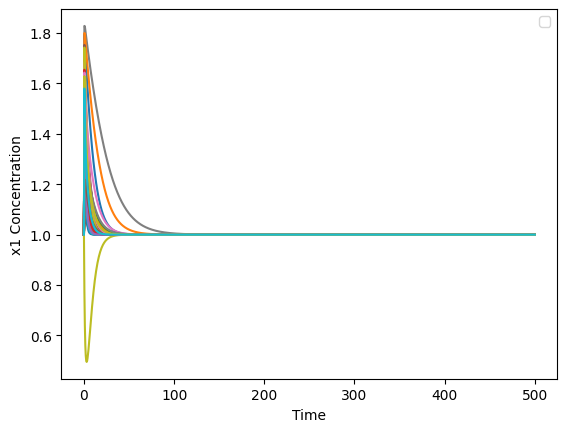

In [10]:
#| output-fig

subs_list = [x for x in crn_vec[0].species if x.material_type not in ['protein', 'complex','metabolite']]

# for sub in subs_list:
sub = subs_list [0]
for ensem_id in range(ensem_size):
    plt.plot(R['time'], R_vec[ensem_id][str(sub)])

plt.legend(sub.name for sub in subs_list)
plt.ylabel(f'{sub.name} Concentration')
plt.xlabel('Time')
# plt.ylim(0.8, 5)

### Interpretation Of The Final Figure

The convergence of concentrations to steady-state values, regardless of the parameter combination in the ensemble, indicates that the model is dynamically consistent and supports the validity of the CRN formulation.